# Modelos de Regresión 

In [ ]:
import sys
!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /usr/local/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [2]:
df = pd.read_csv("train.csv")
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv")
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv")

### Modelo Univariado

In [3]:
X_uni = X_train[["OverallQual"]]

model_uni = sm.OLS(y_train, sm.add_constant(X_uni)).fit()

print(model_uni.summary())


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.617
Method:                 Least Squares   F-statistic:                     1879.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          2.60e-245
Time:                        16:05:03   Log-Likelihood:                -14242.
No. Observations:                1168   AIC:                         2.849e+04
Df Residuals:                    1166   BIC:                         2.850e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -9.023e+04   6421.492    -14.052      

In [4]:
# Eliminar filas con NaN
mask = X_uni["OverallQual"].notna()
X_uni = X_uni[mask]
y_train_uni = y_train[mask]  # usa y_train_uni en el modelo

model_uni = sm.OLS(y_train_uni, sm.add_constant(X_uni)).fit()
y_pred_uni = model_uni.predict(sm.add_constant(X_uni))

residuos = y_train_uni - y_pred_uni

In [5]:
X_uni_const = sm.add_constant(X_uni, has_constant='add')
print(X_uni_const.shape)  # debe ser (1168, 2)

y_pred_uni = model_uni.predict(X_uni_const)
print(y_pred_uni.shape)  # debe ser (1168,)

(1168, 2)
(1168,)


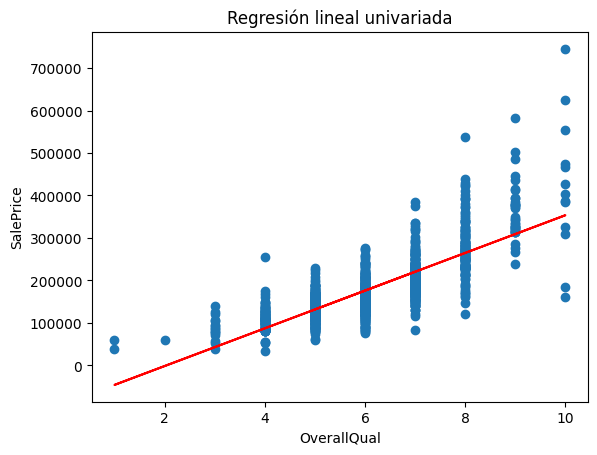

In [6]:
#Predicciones
y_pred_uni = model_uni.predict(sm.add_constant(X_uni))

plt.scatter(X_uni, y_train)
plt.plot(X_uni, y_pred_uni, color="red")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.title("Regresión lineal univariada")
plt.show()


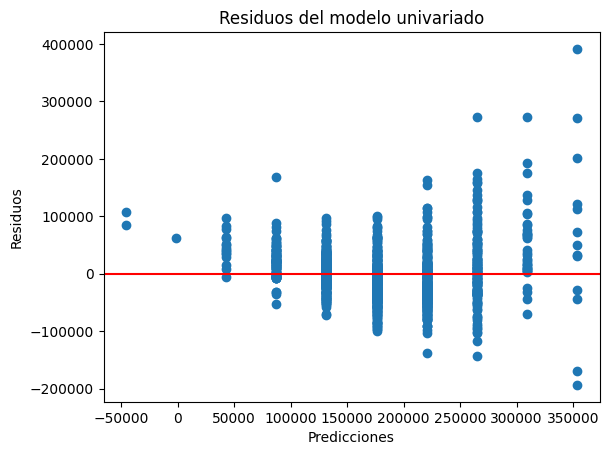

In [7]:
#Análisis de residuos
residuos = y_train.values.flatten() - y_pred_uni

plt.scatter(y_pred_uni, residuos)
plt.axhline(0, color="red")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos del modelo univariado")
plt.show()

### Modelo Multivariado

In [8]:
#Seleccionar solo numéricas
num_vars = df.select_dtypes(include=np.number).columns
num_vars = num_vars.drop("SalePrice")

X_train_num = X_train[num_vars].fillna(X_train[num_vars].median())
X_test_num = X_test[num_vars].fillna(X_test[num_vars].median())

#Modelo
model_multi = sm.OLS(
    y_train,
    sm.add_constant(X_train_num)
).fit()

print(model_multi.summary())



                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.801
Method:                 Least Squares   F-statistic:                     135.5
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:05:14   Log-Likelihood:                -13841.
No. Observations:                1168   AIC:                         2.775e+04
Df Residuals:                    1132   BIC:                         2.794e+04
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -1.274e+05   1.58e+06     -0.081

In [9]:
#Detectar multicolinealidadd
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_num.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_num.values, i)
    for i in range(X_train_num.shape[1])
]

vif_data.sort_values("VIF", ascending=False).head(10)


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab3-MD/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variable,VIF
16,GrLivArea,inf
9,BsmtFinSF1,inf
10,BsmtFinSF2,inf
11,BsmtUnfSF,inf
12,TotalBsmtSF,inf
14,2ndFlrSF,inf
15,LowQualFinSF,inf
13,1stFlrSF,inf
36,YrSold,2.375571e+04
7,YearRemodAdd,2.231117e+04


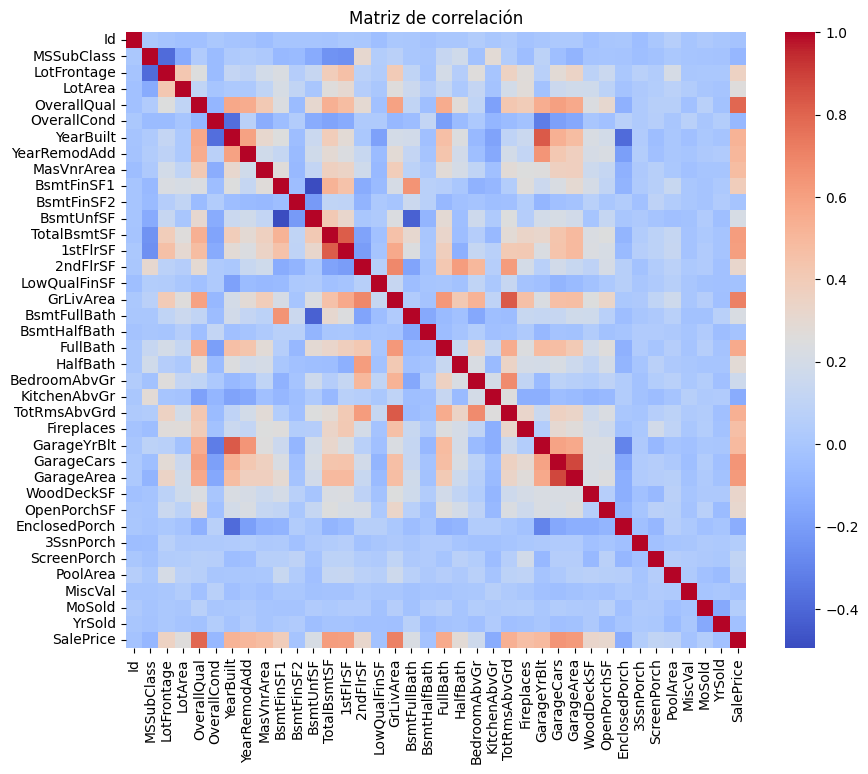

In [10]:
#Matriz de correlación
plt.figure(figsize=(10,8))
sns.heatmap(df[num_vars.tolist() + ["SalePrice"]].corr(), cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()
